# Week 1 实验报告 — Data Source Design & Initial Collection

**项目**: Advanced Chooser Option Pricing Model with Real-World Data & Machine Learning
**目标**: 完成数据需求设计、API 数据管线搭建、初始数据采集 (2018-2024)

## 环境准备

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
DATA_DIR = Path.cwd() / "data"
print(f"数据目录: {DATA_DIR}")
print(f"目录存在: {DATA_DIR.exists()}")

数据目录: d:\models\DINet-master\DINet\week1\data
目录存在: True


## 1. 实验目的

Week 1 的核心任务:
1. **Data Requirement Specification** — 定义三类数据范围
2. **API Setup & Testing** — 配置 Yahoo Finance、Alpha Vantage、FRED 接口
3. **Initial Data Pull** — 采集 JPM 股票日线、3MO 国債收益率、VIX (2018-2024)

## 2. 数据需求设计

| 类别 | 数据字段 | 来源 | 频率 | 用途 |
|---|---|---|---|---|
| 金融市场 | JPM OHLCV | Yahoo Finance | 日 | 期权定价基础资产 |
| 金融市场 | VIX | Yahoo/FRED | 日 | 市场恐慌/波动率代理 |
| 宏观经济 | 3MO 国債收益率 | FRED | 日 | 无风险利率 proxy |

**时间窗口**: 2018-01-01 ~ 2024-12-31（7 年，覆盖 COVID、高通胀、加息周期）

## 3. 数据采集pipline

```
config.py (参数配置)
    ├── yahoo_finance.py  →  Yahoo Chart API v8 (直连)
    ├── alpha_vantage.py →  Alpha Vantage REST API (备选)
    ├── fred_api.py      →  FRED REST API
    └── data_collection.py (主调度器)
              ↓
         data/ (CSV/Parquet)
```

## 4. 采集结果概览

In [17]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
data = {}
for f in csv_files:
    df = pd.read_csv(f)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    data[f.stem] = df
targets = ["yahoo_jpm", "yahoo_vix", "fred_3mo_treasury"]
summary = []
for name in targets:
    df = data.get(name)
    if df is None:
        continue
    summary.append({"文件": name, "行数": len(df), "列数": len(df.columns), "开始日期": df["date"].min().strftime("%Y-%m-%d") if "date" in df.columns else "-", "结束日期": df["date"].max().strftime("%Y-%m-%d") if "date" in df.columns else "-"})
pd.DataFrame(summary)

,文件,行数,列数,开始日期,结束日期
0,yahoo_jpm,1760,9,2018-01-02,2024-12-30
1,yahoo_vix,1760,9,2018-01-02,2024-12-30
2,fred_3mo_treasury,1750,3,2018-01-02,2024-12-31


## 5. 数据可视化

### 5.1 JPM 股价走势 (2018-2024)

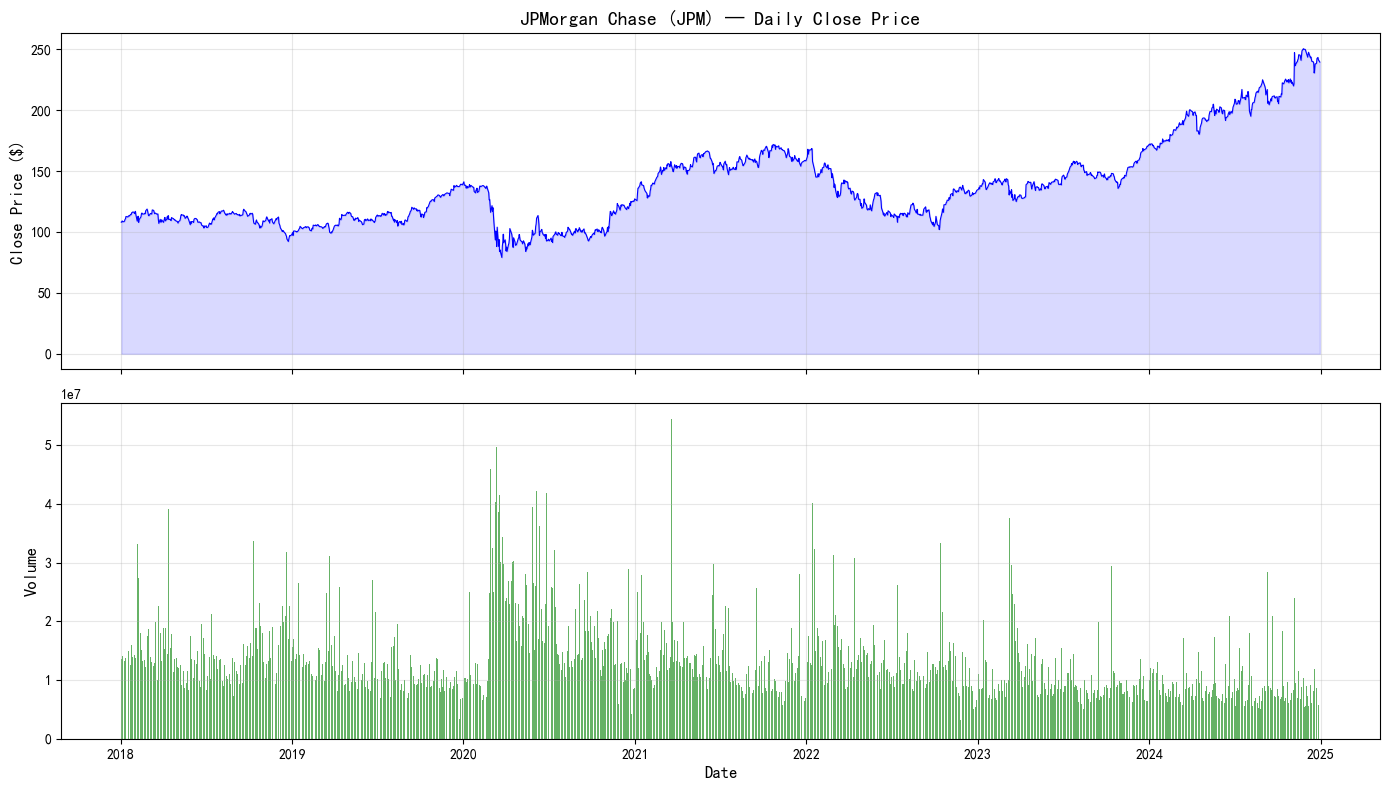

JPM Close Price Statistics
count    1760.00
mean      137.66
std        34.82
min        79.03
25%       111.23
50%       131.46
75%       155.15
max       250.29


In [18]:
jpm = data.get("yahoo_jpm")
if jpm is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(jpm["date"], jpm["close"], linewidth=0.8, color="blue")
    axes[0].fill_between(jpm["date"], jpm["close"], alpha=0.15, color="blue")
    axes[0].set_ylabel("Close Price ($)", fontsize=12)
    axes[0].set_title("JPMorgan Chase (JPM) — Daily Close Price", fontsize=14, fontweight="bold")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(jpm["date"], jpm["volume"], width=1, color="green", alpha=0.6)
    axes[1].set_ylabel("Volume", fontsize=12)
    axes[1].set_xlabel("Date", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout(); plt.show()
    print("=" * 50); print("JPM Close Price Statistics"); print("=" * 50)
    print(jpm["close"].describe().round(2).to_string())

### 5.2 VIX 波动率指数

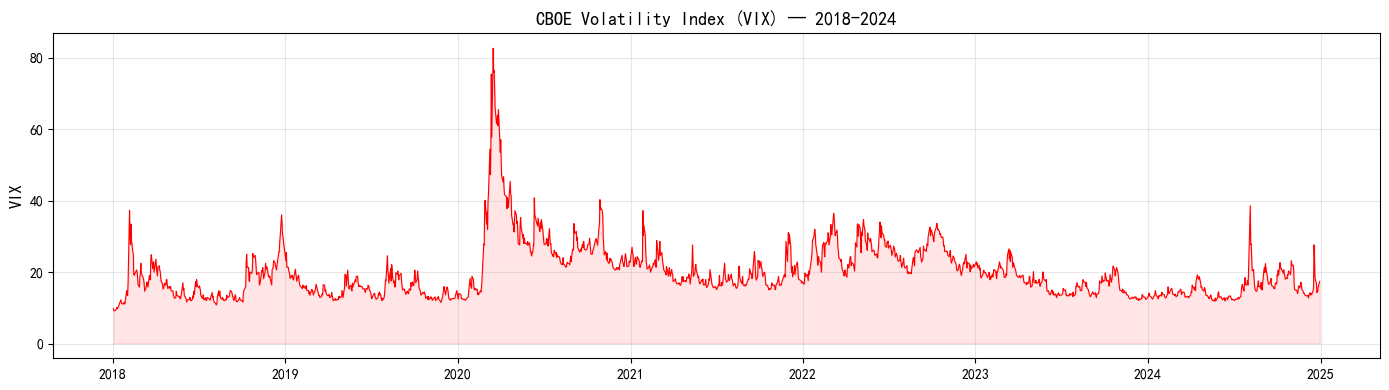

VIX 均值: 19.87
VIX 范围: 9.15 ~ 82.69
VIX 中位数: 18.04


In [19]:
vix = data.get("yahoo_vix")
if vix is not None:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(vix["date"], vix["close"], linewidth=0.8, color="red")
    ax.fill_between(vix["date"], vix["close"], alpha=0.1, color="red")
    ax.set_ylabel("VIX", fontsize=12)
    ax.set_title("CBOE Volatility Index (VIX) — 2018-2024", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout(); plt.show()
    print(f"VIX 均值: {vix['close'].mean():.2f}")
    print(f"VIX 范围: {vix['close'].min():.2f} ~ {vix['close'].max():.2f}")
    print(f"VIX 中位数: {vix['close'].median():.2f}")

### 5.3 3 个月国債收益率

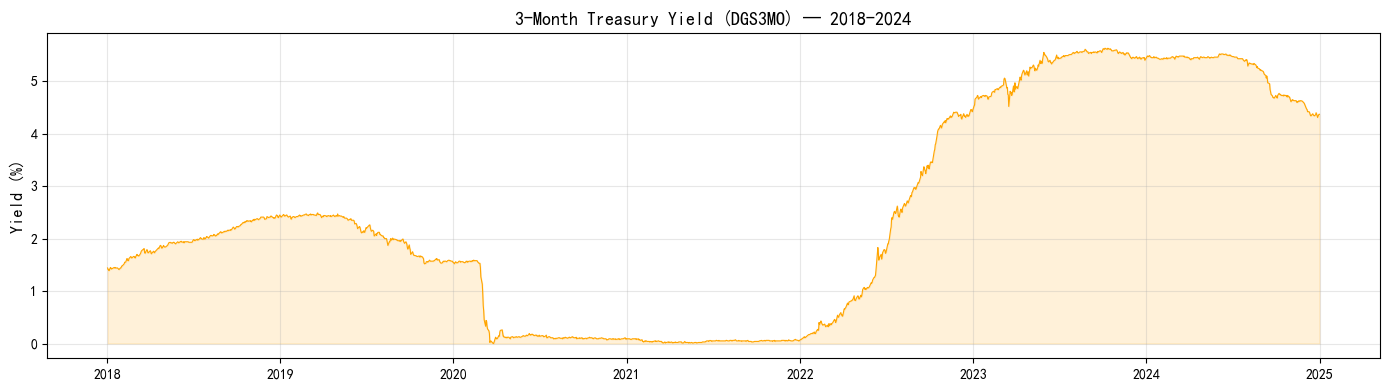

3MO 均值: 2.43%
3MO 范围: 0.00% ~ 5.63%
3MO 中位数: 2.02%


In [20]:
fred_3mo = data.get("fred_3mo_treasury")
if fred_3mo is not None:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fred_3mo["date"], fred_3mo["value"], linewidth=0.8, color="orange")
    ax.fill_between(fred_3mo["date"], fred_3mo["value"], alpha=0.15, color="orange")
    ax.set_ylabel("Yield (%)", fontsize=12)
    ax.set_title("3-Month Treasury Yield (DGS3MO) — 2018-2024", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout(); plt.show()
    print(f"3MO 均值: {fred_3mo['value'].mean():.2f}%")
    print(f"3MO 范围: {fred_3mo['value'].min():.2f}% ~ {fred_3mo['value'].max():.2f}%")
    print(f"3MO 中位数: {fred_3mo['value'].median():.2f}%")

### 5.4 三个时间序列综合对比

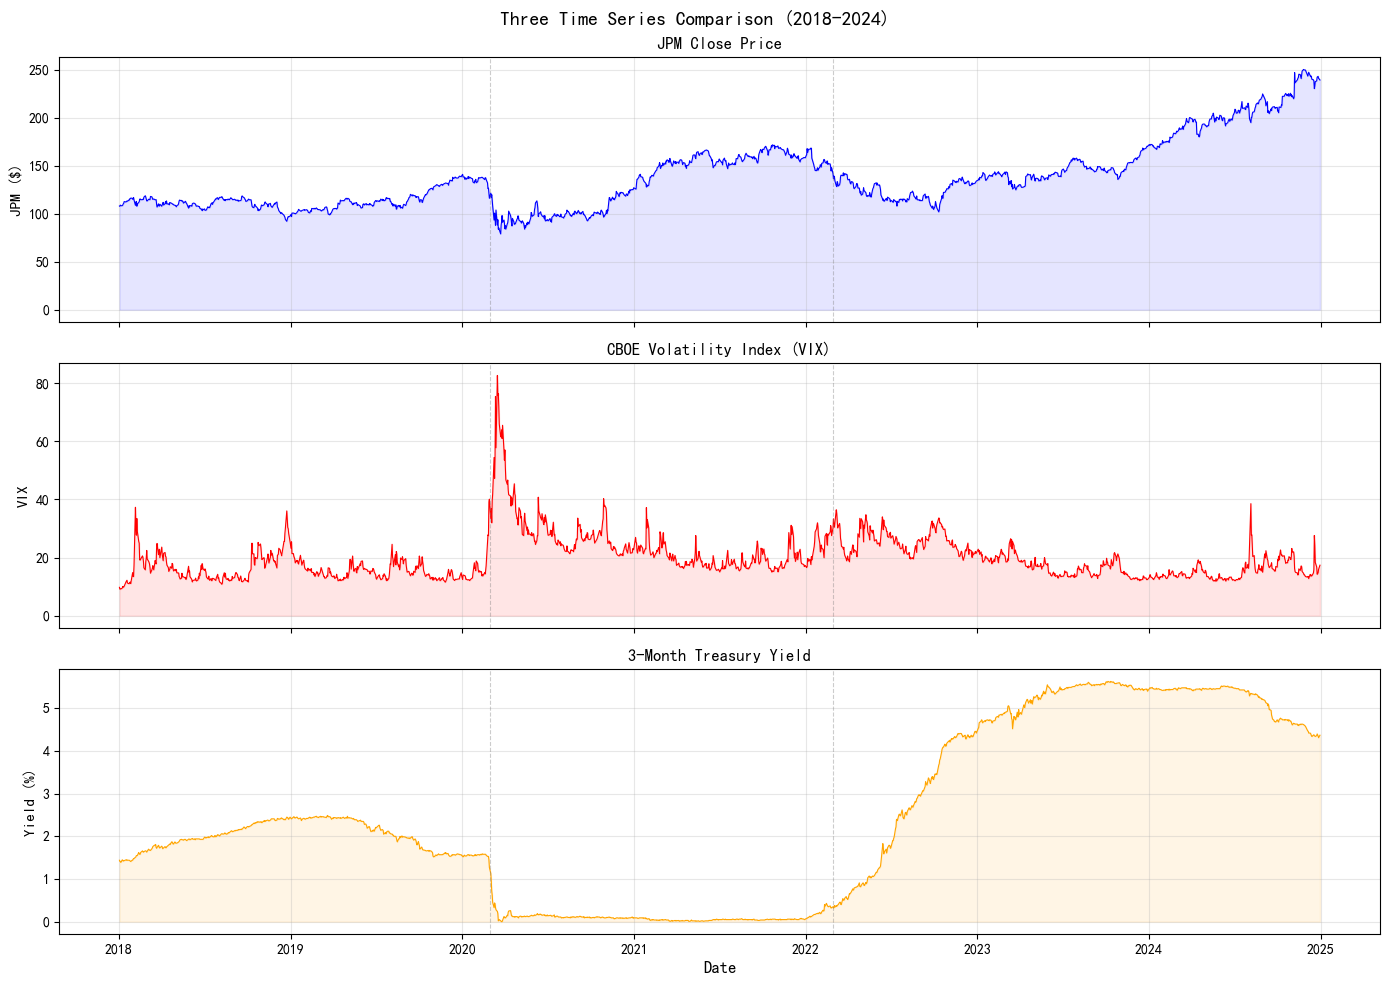

对齐后交易日数: 1747


In [21]:
if jpm is not None and vix is not None and fred_3mo is not None:
    jpm_sub = jpm[["date", "close"]].rename(columns={"close": "JPM_Close"})
    vix_sub = vix[["date", "close"]].rename(columns={"close": "VIX"})
    fred_sub = fred_3mo[["date", "value"]].rename(columns={"value": "3MO_TREASURY"})
    merged = jpm_sub.merge(vix_sub, on="date", how="inner").merge(fred_sub, on="date", how="inner")
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(merged["date"], merged["JPM_Close"], linewidth=0.8, color="blue")
    axes[0].fill_between(merged["date"], merged["JPM_Close"], alpha=0.1, color="blue")
    axes[0].set_ylabel("JPM ($)", fontsize=11); axes[0].set_title("JPM Close Price", fontsize=12, fontweight="bold"); axes[0].grid(True, alpha=0.3)
    axes[1].plot(merged["date"], merged["VIX"], linewidth=0.8, color="red")
    axes[1].fill_between(merged["date"], merged["VIX"], alpha=0.1, color="red")
    axes[1].set_ylabel("VIX", fontsize=11); axes[1].set_title("CBOE Volatility Index (VIX)", fontsize=12, fontweight="bold"); axes[1].grid(True, alpha=0.3)
    axes[2].plot(merged["date"], merged["3MO_TREASURY"], linewidth=0.8, color="orange")
    axes[2].fill_between(merged["date"], merged["3MO_TREASURY"], alpha=0.1, color="orange")
    axes[2].set_ylabel("Yield (%)", fontsize=11); axes[2].set_title("3-Month Treasury Yield", fontsize=12, fontweight="bold"); axes[2].grid(True, alpha=0.3)
    axes[-1].xaxis.set_major_locator(mdates.YearLocator()); axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y")); axes[-1].set_xlabel("Date", fontsize=12)
    for ax in axes:
        ax.axvline(pd.Timestamp("2020-03-01"), color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
        ax.axvline(pd.Timestamp("2022-03-01"), color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
    fig.suptitle("Three Time Series Comparison (2018-2024)", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
    print(f"对齐后交易日数: {len(merged)}")

## 6. 多维度联合分析 — JPM vs 3MO vs VIX

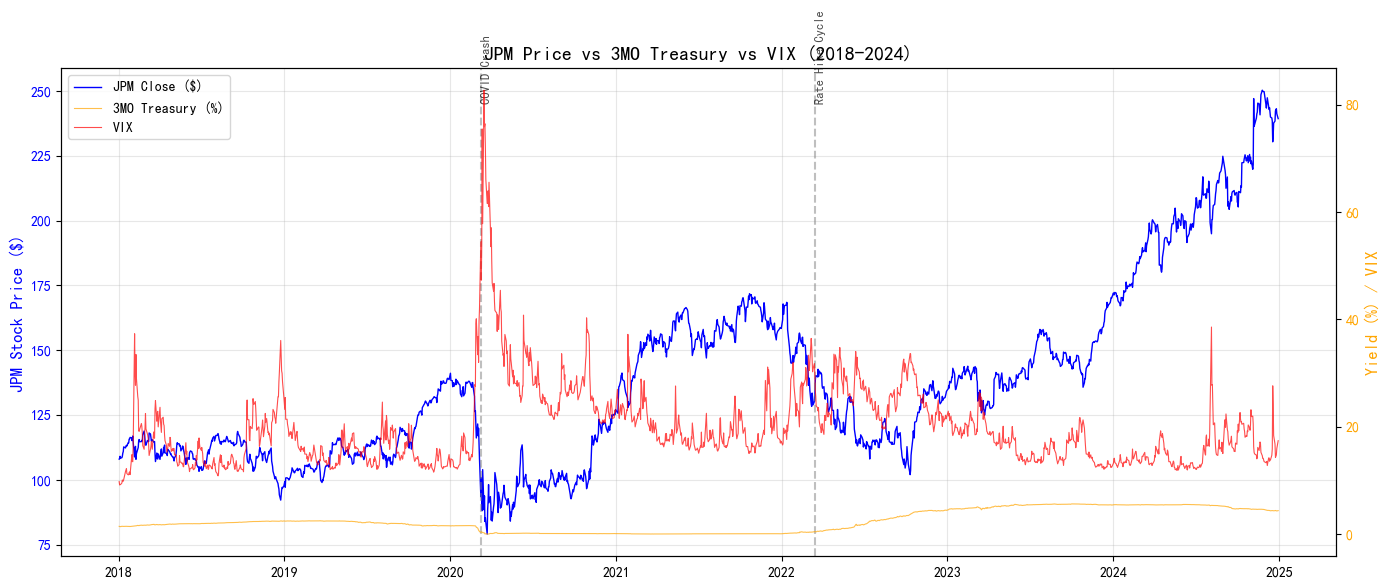

合并后交易日行数: 1747
相关系数 JPM vs 3MO Treasury: 0.475
相关系数 JPM vs VIX: -0.355
相关系数 3MO vs VIX: -0.384


In [22]:
if jpm is not None and fred_3mo is not None and vix is not None:
    jpm_sub = jpm[["date", "close"]].rename(columns={"close": "JPM_Close"})
    vix_sub = vix[["date", "close"]].rename(columns={"close": "VIX"})
    fred_sub = fred_3mo[["date", "value"]].rename(columns={"value": "3MO_TREASURY"})
    merged = jpm_sub.merge(vix_sub, on="date", how="inner").merge(fred_sub, on="date", how="inner")
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(merged["date"], merged["JPM_Close"], color="blue", linewidth=1, label="JPM Close ($)")
    ax1.set_ylabel("JPM Stock Price ($)", color="blue", fontsize=12); ax1.tick_params(axis="y", labelcolor="blue")
    ax2 = ax1.twinx()
    ax2.plot(merged["date"], merged["3MO_TREASURY"], color="orange", linewidth=0.8, alpha=0.7, label="3MO Treasury (%)")
    ax2.plot(merged["date"], merged["VIX"], color="red", linewidth=0.8, alpha=0.7, label="VIX")
    ax2.set_ylabel("Yield (%) / VIX", color="orange", fontsize=12); ax2.tick_params(axis="y", labelcolor="orange")
    for ds, lab in [("2020-03-09", "COVID Crash"), ("2022-03-16", "Rate Hike Cycle")]:
        ax1.axvline(pd.Timestamp(ds), color="gray", linestyle="--", alpha=0.5)
        ax1.text(pd.Timestamp(ds), ax1.get_ylim()[1] * 0.95, lab, rotation=90, fontsize=9, alpha=0.7)
    l1, l2 = ax1.get_legend_handles_labels(); l3, l4 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l3, l2 + l4, loc="upper left", fontsize=10)
    ax1.set_title("JPM Price vs 3MO Treasury vs VIX (2018-2024)", fontsize=14, fontweight="bold"); ax1.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"合并后交易日行数: {len(merged)}")
    print(f"相关系数 JPM vs 3MO Treasury: {merged['JPM_Close'].corr(merged['3MO_TREASURY']):.3f}")
    print(f"相关系数 JPM vs VIX: {merged['JPM_Close'].corr(merged['VIX']):.3f}")
    print(f"相关系数 3MO vs VIX: {merged['3MO_TREASURY'].corr(merged['VIX']):.3f}")

## 7. 遇到的问题与解决方案

### 7.1 Yahoo Finance 限流 (YFRateLimitError)
- **问题**: yfinance 库被 Yahoo 限流
- **方案**: 直连 Yahoo Chart API v8，添加浏览器模拟 Header + 指数退避重试

### 7.2 Alpha Vantage 付费限制
- **问题**: TIME_SERIES_DAILY_ADJUSTED 为 Premium 端点
- **方案**: 自动降级到免费版，但仅返回最近 100 天，不满足 7 年窗口

### 7.3 部分数据时间长度不一致
- **问题**: 进行相关性可视化比较需要保证时间序列长度一致
- **方案**: 暂时采用inner join的关联方式保证只检验两者都有的日期数据

## 8. 数据质量评估

In [23]:
print("=" * 60); print("Data Quality Report"); print("=" * 60)
for name in targets:
    df = data.get(name)
    if df is None: continue
    print(f"\n--- {name} ---")
    print(f"  Shape: {df.shape}")
    print(f"  Duplicated rows: {df.duplicated().sum()}")
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if len(null_cols) > 0: print(f"  Null values:\n{null_cols.to_string()}")
    else: print("  No null values")

Data Quality Report

--- yahoo_jpm ---
  Shape: (1760, 9)
  Duplicated rows: 0
  No null values

--- yahoo_vix ---
  Shape: (1760, 9)
  Duplicated rows: 0
  No null values

--- fred_3mo_treasury ---
  Shape: (1750, 3)
  Duplicated rows: 0
  No null values


## 9. 总结

### Week 1 交付状态

| 交付物 | 状态 | 备注 |
|---|---|---|
| 数据需求文档 | ✅ | data_specification.md |
| API 连接脚本 | ✅ | yahoo_finance.py / alpha_vantage.py / fred_api.py 三模块 |
| 初始数据集 | ✅ | JPM / VIX / 3MO Treasury (2018-2024) |

## 10. Week 2 任务理解

### 核心任务: Data Preprocessing & Feature Engineering

Week 1 完成了原始数据采集，Week 2 则需要将这些数据处理为可用的特征矩阵，供后续 BSM 模型和 ML 模型使用。

### 10.1 数据清洗 (Data Cleaning)

| 工作 | 说明 |
|---|---|
| **缺失值处理** | 节假日对齐后出现 NaN，使用插值（interpolation）或向前填充（forward fill）补全 |
| **异常值检测** | 用 IQR（四分位距）方法识别极端价格跳变或错误的数据 |
| **时间对齐** | JPM（交易日 1760 行）与 3MO（交易日 1750 行）做 inner join 对齐，确保每行都有完整数据 |

### 10.2 特征工程 (Feature Engineering)

**传统特征**:
- **滚动波动率(Rolling Volatility)**: 过去 5个交易日（1周） /20个交易日（1月）/60个交易日（1季度）的收益率标准差
- **日收益率(Daily Return)**: `(close[t] - close[t-1]) / close[t-1]`
- **股息增长率(dividend growth)**: 公司每股股息（DPS）随时间的变化率

**高级特征**:
- **JPM-VIX 相关性(VIX-JPM correlation)** : 滚动窗口内 JPM 与 VIX 的相关性（市场恐慌对股价的影响）
- **利率动量(Interest rate momentum)** : 3MO 国債收益率的短期变化趋势（利率政策的预期）<br>
  三种计算方法:
  - (1) `IR_Mom[t]=r[t]-r[t-n]`(N日变化)
  - (2) `IR_Mom[t]=(r[t]/r[t-n])-1`（百分比动量）
  - (3) `IR_Mom[t]=(r[t]-μ[n])/σ[n]` (标准化动量)
- **情绪评分 (Sentiment Score, 0–1)**: 基于 VIX 滚动窗口标准化，$Score_t = 1 - \frac{VIX_t - \min(VIX_{t-w:t})}{\max(VIX_{t-w:t}) - \min(VIX_{t-w:t})}$，值域 [0,1]，越高越乐观。


### 10.3 自动化pipline

将清洗 + 特征工程封装为一个可复用的 Pipeline：
- 输入: 原始 CSV
- 输出: 特征矩阵（CSV/Parquet），可直接喂入模型
- 可配置参数（窗口大小、阈值等）

### 10.4 与 Chooser Option Pricing 的关联

这些特征的最终目的是改进 BSM 模型的**波动率预测**:

```
传统 BSM:     固定波动率 → 定价偏差大
方法:  ML 预测波动率 → 输入 BSM → 更精准定价
             ↑
       特征来自: VIX相关性、利率动量、滚动波动率...
```

### 10.5 交付物清单

| 交付物 | 说明 |
|---|---|
| 清洗后的结构化数据集 | CSV/Parquet，≥10 个特征 |
| 自动化预处理 Pipeline 代码 | 可复用的 Python 模块 |
| 特征工程文档 | 每个特征的定义和计算方式 |